### Importación de Librerías y Configuración
Este bloque prepara el entorno de trabajo y define las rutas de datos.
Usa `Path` para construir rutas de archivo reproducibles y asegura que `data/processed` exista.


In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import joblib

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Rutas del proyecto
BASE_DIR = Path("..")
RAW_DATA_PATH = BASE_DIR / "data" / "raw"
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"

# Crear directorio procesado si no existe
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)
print("✅ Librerías cargadas y rutas configuradas correctamente.")

✅ Librerías cargadas y rutas configuradas correctamente.


### Carga de Datos Crudos
Este paso importa el dataset original para análisis exploratorio y particionado.
El dataset contiene `Time`, `Amount`, `Class` y las 28 características PCA `V1`..`V28`.


In [3]:
# Cargar dataset de tarjetas de crédito
df_full = pd.read_csv(RAW_DATA_PATH / "creditcard.csv")

print(f"Dataset de tarjetas de crédito (filas, columnas): {df_full.shape}")
df_full.head()

Dataset de tarjetas de crédito (filas, columnas): (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Exploración Inicial (EDA)
Revisamos nulos y distribución de clases para validar la calidad del dataset.
Esto confirma el carácter altamente desbalanceado del problema de fraude.


In [4]:
# Verificar valores nulos
print("🔍 Cantidad de valores nulos en el dataset:", df_full.isnull().sum().sum())

# Mapeo de clases para legibilidad (0: Normal/Lícita, 1: Fraudulenta/Ilícita)
class_map = {0: 'Lícita (0)', 1: 'Ilícita (1)'}
df_full['class_label'] = df_full['Class'].map(class_map)

# Distribución general de clases
print("\n📊 Distribución de Clases:")
print(df_full['class_label'].value_counts(dropna=False))

print("\n📈 Porcentaje de Distribución:")
print(df_full['class_label'].value_counts(normalize=True) * 100)

🔍 Cantidad de valores nulos en el dataset: 0

📊 Distribución de Clases:
class_label
Lícita (0)     284315
Ilícita (1)       492
Name: count, dtype: int64

📈 Porcentaje de Distribución:
class_label
Lícita (0)     99.827251
Ilícita (1)     0.172749
Name: proportion, dtype: float64


### Visualización de la Distribución de Clases

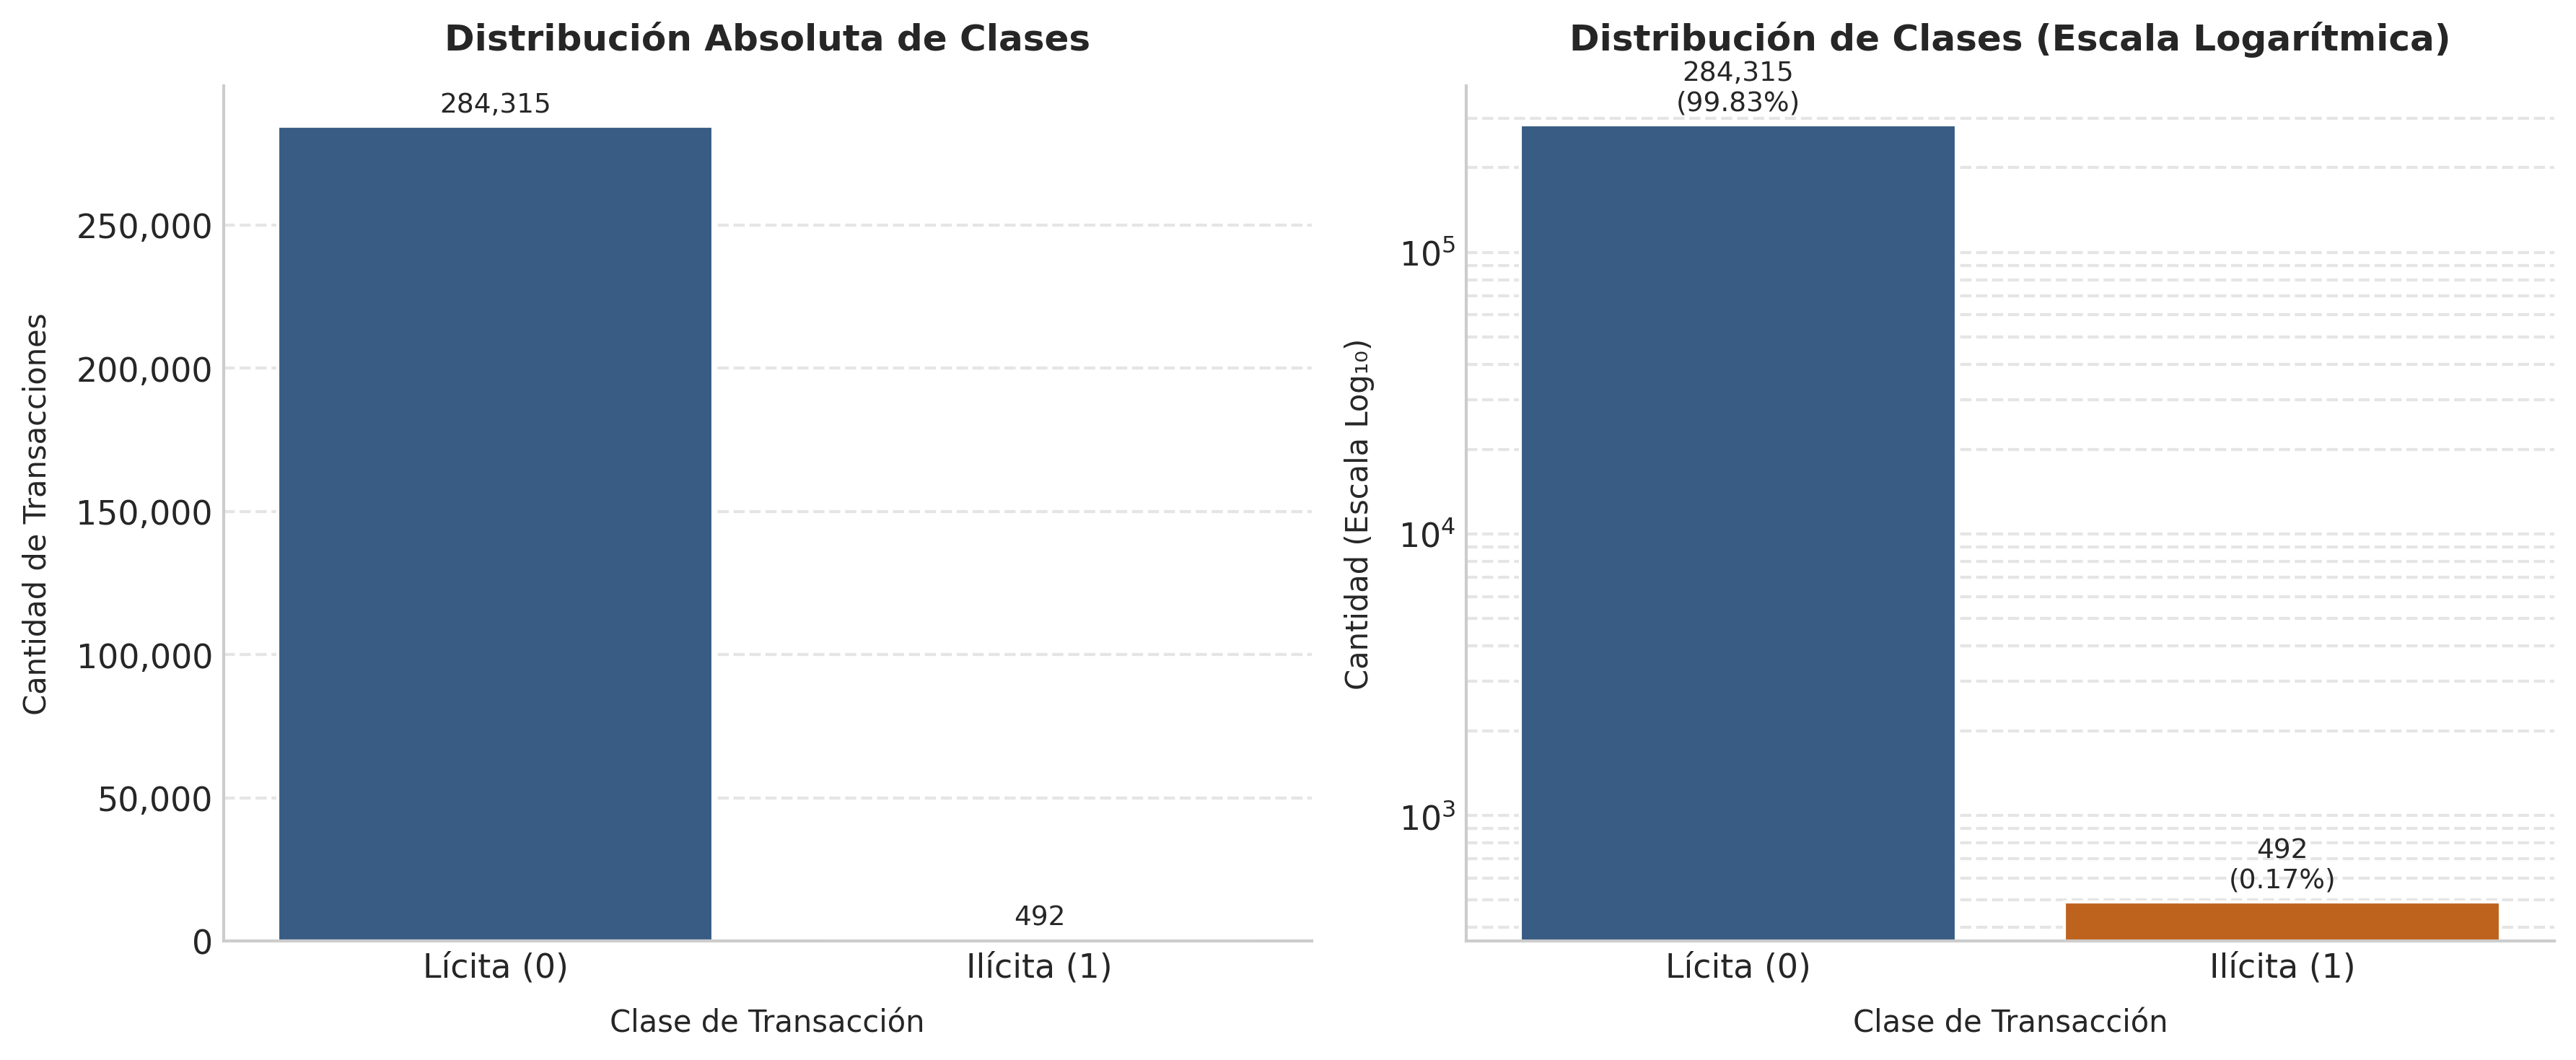

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo global para rigor científico
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# Paleta semántica con las claves exactas que tiene tu dataframe
palette = {'Lícita (0)': '#2b5c8f', 'Ilícita (1)': '#d95f02'}

# --- Gráfico 1: Escala Lineal ---
ax1 = axes[0]
sns.countplot(data=df_full, x='class_label', hue='class_label', palette=palette, ax=ax1, legend=False)
ax1.set_title("Distribución Absoluta de Clases", fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel("Clase de Transacción", fontsize=10, labelpad=8)
ax1.set_ylabel("Cantidad de Transacciones", fontsize=10, labelpad=8)
ax1.yaxis.set_major_formatter('{x:,.0f}')  # Separador de miles
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)

# Añadir valores exactos sobre las barras
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{int(height):,}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                     textcoords='offset points')

# --- Gráfico 2: Escala Logarítmica ---
ax2 = axes[1]
sns.countplot(data=df_full, x='class_label', hue='class_label', palette=palette, ax=ax2, legend=False)
ax2.set_yscale('log')
ax2.set_title("Distribución de Clases (Escala Logarítmica)", fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel("Clase de Transacción", fontsize=10, labelpad=8)
ax2.set_ylabel("Cantidad (Escala Log₁₀)", fontsize=10, labelpad=8)
ax2.grid(axis='y', which='both', linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)

# Añadir valores/porcentajes sobre las barras en escala logarítmica
total = len(df_full)
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        pct = (height / total) * 100
        ax2.annotate(f'{int(height):,}\n({pct:.2f}%)',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                     textcoords='offset points')

# Eliminar marcos superior y derecho
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

### Preprocesamiento y Escalado de Características (`Time` y `Amount`)
Tras verificar el dataset, escalamos sólo `Time` y `Amount` para evitar data leakage.
Las características `V1`..`V28` ya están normalizadas por PCA, por lo que no se reescalan.


In [6]:
# 1. Copia de trabajo y reordenamiento inicial
# Se usa una copia para no alterar el dataframe original cargado.
df_processed = df_full.copy()
df_processed.drop(columns=['class_label'], inplace=True, errors='ignore')

# Reordenar para dejar la variable objetivo 'Class' al final
cols = [col for col in df_processed.columns if col != 'Class'] + ['Class']
df_processed = df_processed[cols]

# 2. División preliminar por clases
# El autoencoder se entrena solo con transacciones normales (Clase 0).
df_normal = df_processed[df_processed['Class'] == 0].copy()
df_fraud = df_processed[df_processed['Class'] == 1].copy()

# Split de la clase normal (60% Train, 20% Val, 20% Test)
normal_train, normal_holdout = train_test_split(
    df_normal,
    test_size=0.4,
    random_state=42,
    shuffle=True
)
normal_val, normal_test = train_test_split(
    normal_holdout,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

# Split de la clase fraudulenta (50% Val, 50% Test)
# Las transacciones fraudulentas no se usan para entrenar el autoencoder.
fraud_val, fraud_test = train_test_split(
    df_fraud,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

# Unir y mezclar los conjuntos de Validación y Test
df_val = pd.concat([normal_val, fraud_val]).sample(frac=1, random_state=42).reset_index(drop=True)
df_test = pd.concat([normal_test, fraud_test]).sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Ajuste de Escaladores SIN Data Leakage
# Ajustamos los escaladores solo con el conjunto de entrenamiento normal.
scaler_amount = RobustScaler()
scaler_time = RobustScaler()

# Copia explícita para evitar SettingWithCopyWarning
df_train = normal_train.copy().reset_index(drop=True)

# Fit solo en entrenamiento normal
df_train['scaled_amount'] = scaler_amount.fit_transform(df_train[['Amount']])
df_train['scaled_time'] = scaler_time.fit_transform(df_train[['Time']])

# Transform en validación y test usando los parámetros aprendidos
df_val['scaled_amount'] = scaler_amount.transform(df_val[['Amount']])
df_val['scaled_time'] = scaler_time.transform(df_val[['Time']])

df_test['scaled_amount'] = scaler_amount.transform(df_test[['Amount']])
df_test['scaled_time'] = scaler_time.transform(df_test[['Time']])

# Eliminar columnas originales sin escalar
for df in [df_train, df_val, df_test]:
    df.drop(columns=['Time', 'Amount'], inplace=True)

# Definir columnas de características
feature_columns = [col for col in df_train.columns if col != 'Class']

# Extraer matrices NumPy
X_train_licit = df_train[feature_columns].values
X_val = df_val[feature_columns].values
X_test = df_test[feature_columns].values

y_val = df_val['Class'].values
y_test = df_test['Class'].values

print("✅ División de datos y escalado completados correctamente:")
print(f"   - X_train_licit: {X_train_licit.shape}")
print(f"   - X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"   - X_test: {X_test.shape}, y_test: {y_test.shape}")

✅ División de datos y escalado completados correctamente:
   - X_train_licit: (170589, 30)
   - X_val: (57109, 30), y_val: (57109,)
   - X_test: (57109, 30), y_test: (57109,)


### Guardado de Datos Procesados y Artefactos
Preservamos artefactos reproducibles para entrenamiento, validación y test.
Los escaladores guardados permiten aplicar la misma transformación en inferencia futura.


In [7]:

# 4. Guardar artefactos corregidos
np.save(PROCESSED_DATA_PATH / "X_train_licit.npy", X_train_licit)
np.save(PROCESSED_DATA_PATH / "X_val.npy", X_val)
np.save(PROCESSED_DATA_PATH / "X_test.npy", X_test)
np.save(PROCESSED_DATA_PATH / "y_val.npy", y_val)
np.save(PROCESSED_DATA_PATH / "y_test.npy", y_test)

joblib.dump(scaler_amount, PROCESSED_DATA_PATH / "scaler_amount.pkl")
joblib.dump(scaler_time, PROCESSED_DATA_PATH / "scaler_time.pkl")

print(f"📦 Arrays y escaladores guardados correctamente en: {PROCESSED_DATA_PATH}")

📦 Arrays y escaladores guardados correctamente en: ..\data\processed
